Implementing the Game of life by Conway.
We should use a numpy array of zeros and ones to model the world our cells live in. Furthermore there has to be a function which determins the time evolution of the system accordingly to the rules.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FuncFormatter
from IPython.display import HTML
import scipy as sp

Here wehave the rules and the animation.

In [2]:
N = 300
frames = 1000
interval = 100

def count_neighbors(world):
    return ( np.roll(world,1,0) + np.roll(world,-1,0) + np.roll(world,1,1) + np.roll(world,-1,1) +
             np.roll(np.roll(world,1,0),1,1) + np.roll(np.roll(world,1,0),-1,1) + 
             np.roll(np.roll(world,-1,0),1,1) + np.roll(np.roll(world,-1,0),-1,1) )

def evolve(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

# world = np.zeros((N,N))
# # for i in range(T):
# #     world = evolve(world)
# initial_density = 0.6
# aux_world = np.random.random((100,100))
# aux_world[aux_world > initial_density] = 0
# aux_world[aux_world != 0] = 1
# world[100:200,100:200] = aux_world
# fig, ax = plt.subplots(figsize=(6,6))
# ax.axis('off')
# img = ax.imshow(np.zeros((N,N,3)), interpolation='nearest')

# def update(frame):
#     global world
#     world = evolve(world)
#     rgb = np.zeros((N,N,3))
#     rgb[world==1] = [0, 1, 1]
#     rgb[world==0] = [0, 0, 0]
#     img.set_data(rgb)
#     return [img]

# ani = FuncAnimation(fig, update, frames=frames, interval=interval, blit=True)

# HTML(ani.to_jshtml())



Density vs time. Initial density is a crucial parameter.

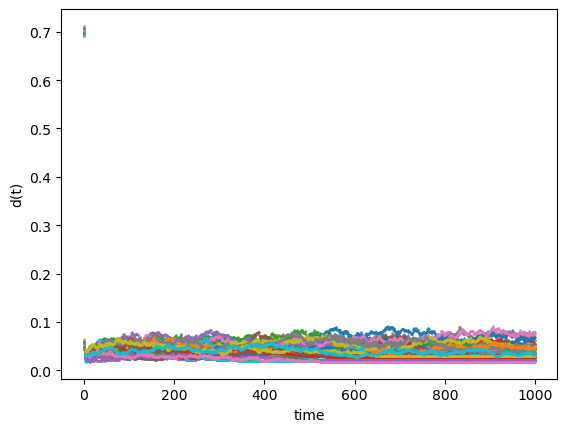

In [4]:
N = 100
T = 1000
trajectories = 50
time = np.arange(T)
initial_density = 0.7
densities = []
for i in range(trajectories):
    aux_density = []
    world = np.random.random((N,N))
    world[world > initial_density] = 0
    world[world != 0] = 1
    for j in range(T):
        aux_density.append(np.sum(world == 1)/N**2)
        world = evolve(world)
    plt.scatter(time,aux_density, s = 0.5)
    densities.append(aux_density)
plt.xlabel("time")
# plt.xlim(200,T)
# plt.ylim(0,0.2)
plt.ylabel("d(t)")
plt.show()
densities = np.array(densities)

How are the trajectories distributed over the phase space?

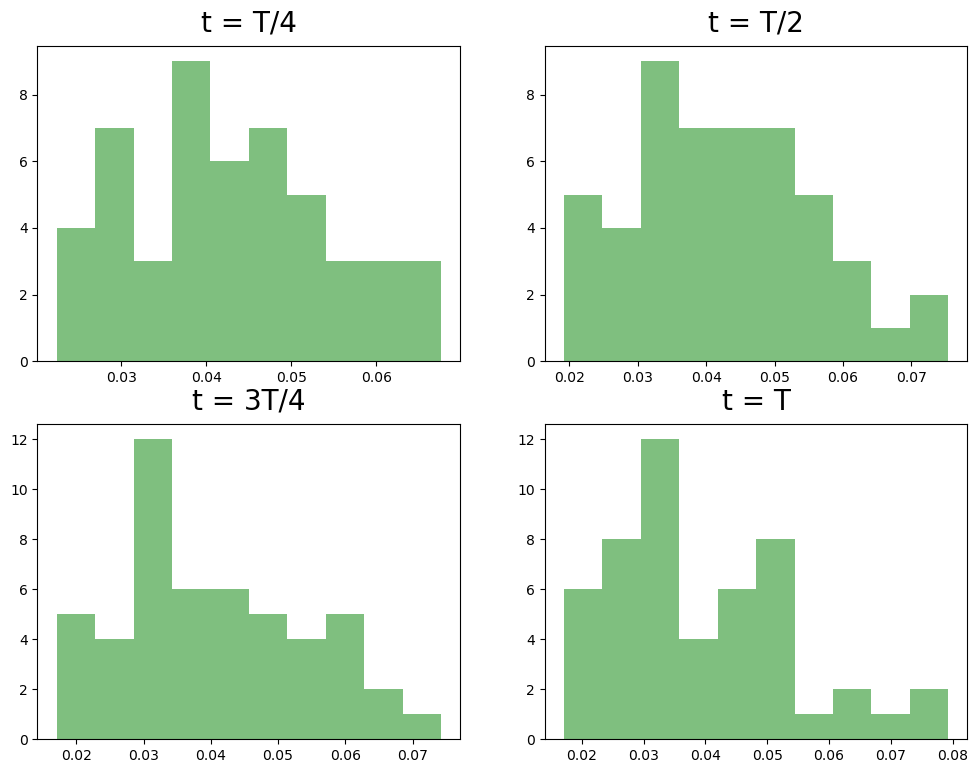

In [5]:

fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize=(12, 9))

ax[0][0].hist(densities[:,int(T/4)],10, histtype = 'stepfilled', alpha = 0.5, color = 'green')
# ax[0][0].yaxis.set_major_locator(MultipleLocator(2))
# ax[0][0].xaxis.set_major_locator(MultipleLocator(0.01))
ax[0][0].set_title("t = T/4", fontsize=20, verticalalignment='bottom')

ax[0][1].hist(densities[:,int(T/2)],10, histtype = 'stepfilled', alpha = 0.5, color = 'green')
# ax[0][1].yaxis.set_major_locator(MultipleLocator(2))
# ax[0][1].xaxis.set_major_locator(MultipleLocator(0.01))
ax[0][1].set_title("t = T/2", fontsize=20, verticalalignment='bottom')

ax[1][0].hist(densities[:,int(3*T/4)],10, histtype = 'stepfilled', alpha = 0.5, color = 'green')
# ax[1][0].yaxis.set_major_locator(MultipleLocator(2))
# ax[1][0].xaxis.set_major_locator(MultipleLocator(0.01))
ax[1][0].set_title("t = 3T/4", fontsize=20, verticalalignment='bottom')

ax[1][1].hist(densities[:,T-1],10, histtype = 'stepfilled', alpha = 0.5, color = 'green')
# ax[1][1].yaxis.set_major_locator(MultipleLocator(2))
# ax[1][1].xaxis.set_major_locator(MultipleLocator(0.01))
ax[1][1].set_title("t = T", fontsize=20, verticalalignment='bottom')
plt.show()

We can use mean and std and analyze them.

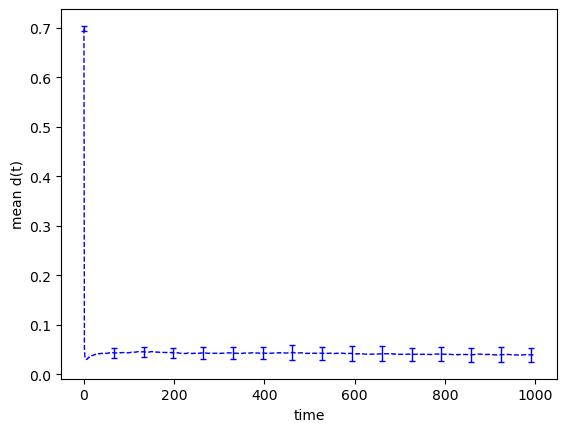

In [6]:
mean_density = densities.mean(axis=0)
std_density = densities.std(axis=0)
idx = list(range(0,T,int(T/15)))
plt.errorbar(time[idx],mean_density[idx],std_density[idx], ls = '', lw = 1, capsize = 2, color = 'blue')
plt.plot(time,mean_density, ls = '--', lw = 1, color = 'blue')
plt.xlabel("time")
plt.ylabel("mean d(t)")
plt.show()

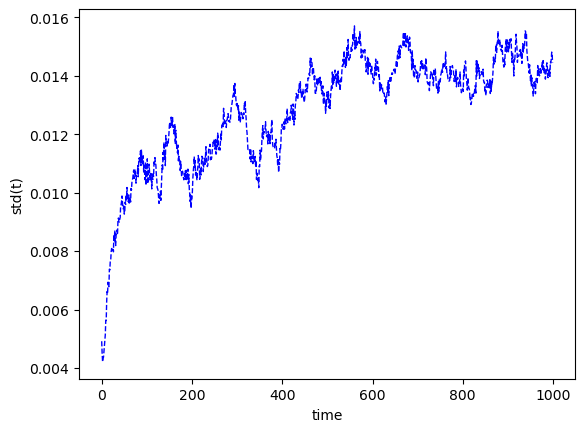

In [7]:
plt.plot(time, std_density, ls = '--', lw = 1, color = 'blue')
#plt.scatter(time[idx], std_density[idx], s = 5, color = 'blue')
plt.xlabel("time")
plt.ylabel("std(t)")
plt.show()

Now we study the asymptotic density.

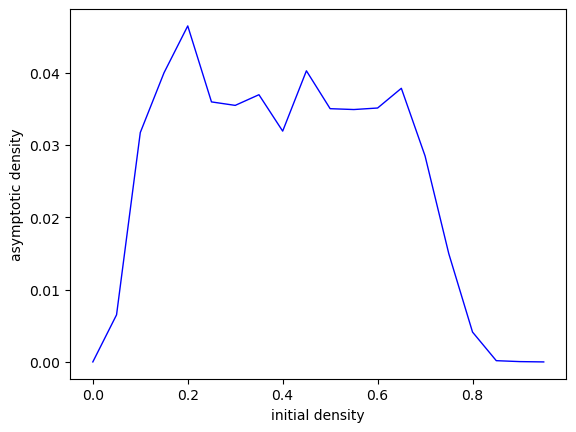

In [7]:
N = 180
T = 1800
trajectories = 5
initial_density = np.arange(0,1,0.05)
asymptotic_density = []
for i_d in initial_density:
    aux_d = 0
    for i in range(trajectories):
        world = world = np.random.random((N,N))
        world[world > i_d] = 0
        world[world != 0] = 1
        for j in range(T):
            world = evolve(world)
        aux_d += (1/trajectories)*np.sum(world==1)/N**2
    asymptotic_density.append(aux_d)
plt.plot(initial_density, asymptotic_density, lw = 1, color = 'blue')
plt.xlabel('initial density')
plt.ylabel('asymptotic density')
plt.show()

What about the rate of change?

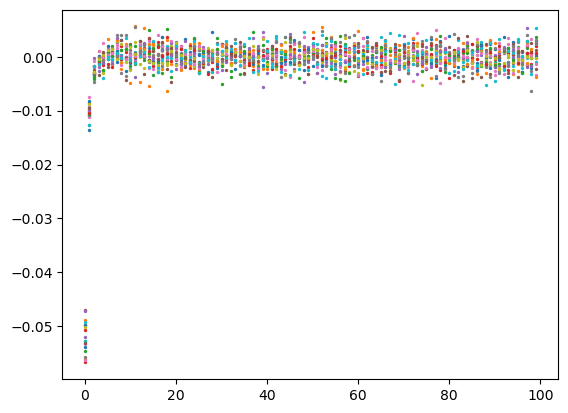

In [8]:
N = 100
T = 100
trajectories = 20
time = np.arange(T)
initial_density = 0.1
densities = []
rate_of_change = []
for i in range(trajectories):
    aux_density = []
    aux_rate = []
    world = np.random.random((N,N))
    world[world > initial_density] = 0
    world[world != 0] = 1
    for j in range(T):
        aux_density.append(np.sum(world == 1)/N**2)
        world = evolve(world)
        aux_rate.append(np.sum(world == 1)/N**2-aux_density[j])
    densities.append(aux_density)
    rate_of_change.append(aux_rate)
densities = np.array(densities)
rate_of_change = np.array(rate_of_change)
for i in range(len(rate_of_change)):
    plt.scatter(time,rate_of_change[i], s = 2)
plt.show()

We saw that starting from an initial density in the range of 0.1-0.7 for large t we reach a steady state around 0.025. What large t means is still not clear, but based on our observations and on the article of interest t = 8000 should be sufficient. At this point we start from a fixed initial density and we generate many trajectories. For each of them we calculate d(large t) as the mean over time of d(t) for 8000 < t < 9000. We then calculate d* as the mean over all trajectories of the latter quantity. It is interesting to understand how d(t) approaches d* depending on the size of the lattice. 

### Determining d*

In [10]:
initial_density = 0.4
L = np.array([80,150,300])
#L=np.array([50,100])
def count_neighbors(world):
    return ( np.roll(world,1,0) + np.roll(world,-1,0) + np.roll(world,1,1) + np.roll(world,-1,1) +
             np.roll(np.roll(world,1,0),1,1) + np.roll(np.roll(world,1,0),-1,1) + 
             np.roll(np.roll(world,-1,0),1,1) + np.roll(np.roll(world,-1,0),-1,1) )

def evolve(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

T = 9000
DT = 500
trajectories = 10
time = np.arange(T,T+DT)

#final_d = 0
for l in L:
    print("Lattice size: ", l,"x", l)
    densities = []
    for i in range(trajectories):
        aux_density = []
        world = np.random.random((l,l))
        world[world > initial_density] = 0
        world[world != 0] = 1
        for j in range(T):
            world = evolve(world)
        for j in range(T,T+DT):
            world = evolve(world)
            #final_d += 1/(trajectories*DT)*np.sum(world == 1)/l**2
            aux_density.append(np.sum(world == 1)/l**2)
        densities.append(aux_density)
    densities = np.array(densities)
    print("mean: ", np.mean(densities))
    print("std: ", np.std(densities))

Lattice size:  80 x 80
mean:  0.028187499999999994
std:  0.004401260472864564
Lattice size:  150 x 150
mean:  0.030155555555555554
std:  0.001342376738714574
Lattice size:  300 x 300
mean:  0.02864222222222222
std:  0.0009643689166534805
Lattice size:  500 x 500


KeyboardInterrupt: 

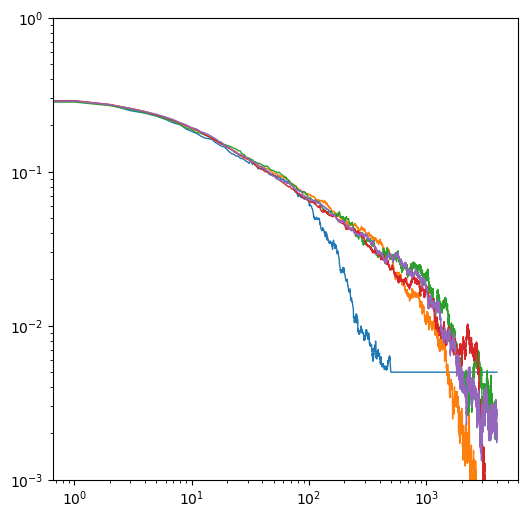

In [8]:
initial_density = 0.4
L = np.array([15, 50, 100, 150, 200])
#L=np.array([50,100])
def count_neighbors(world):
    return ( np.roll(world,1,0) + np.roll(world,-1,0) + np.roll(world,1,1) + np.roll(world,-1,1) +
             np.roll(np.roll(world,1,0),1,1) + np.roll(np.roll(world,1,0),-1,1) + 
             np.roll(np.roll(world,-1,0),1,1) + np.roll(np.roll(world,-1,0),-1,1) )

def evolve(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

T = 4000

trajectories = np.array([200, 70, 10, 10, 5])
time = np.arange(T)
mean_densities = []
for k in range(len(L)):
    densities = []
    for i in range(trajectories[k]):
        aux_density = []
        world = np.random.random((L[k],L[k]))
        world[world > initial_density] = 0
        world[world != 0] = 1
        for j in range(T):
            world = evolve(world)
            aux_density.append(np.sum(world == 1)/L[k]**2 - 0.0287)
        densities.append(aux_density)
    densities = np.array(densities)
    mean_densities.append(densities.mean(axis = 0))
fig, ax1 = plt.subplots(figsize = (6,6))
for d in mean_densities:
    ax1.plot(time, d, lw = 1)
ax1.set_ylim(0.001,1)
ax1.set_yscale('log')
ax1.set_xscale('log')
plt.show()

In [16]:
print(mean_densities[-1])

[0.33361  0.287495 0.272535 ... 0.00222  0.00209  0.002275]


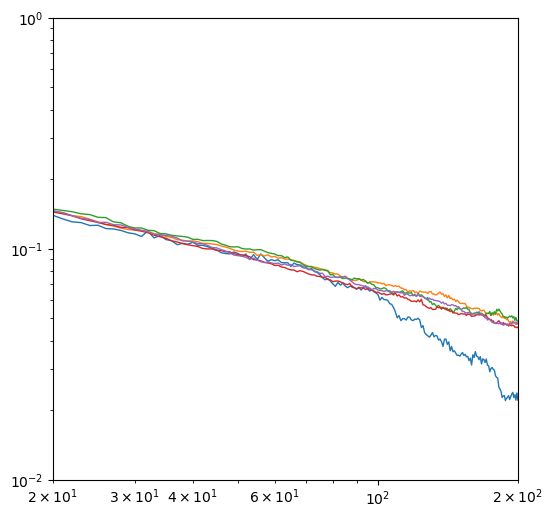

In [9]:
fig, ax1 = plt.subplots(figsize = (6,6))
for d in mean_densities:
    ax1.plot(time, d, lw = 1)
ax1.set_ylim(0.01,1)
ax1.set_xlim(20,200)
ax1.set_yscale('log')
ax1.set_xscale('log')
plt.show()

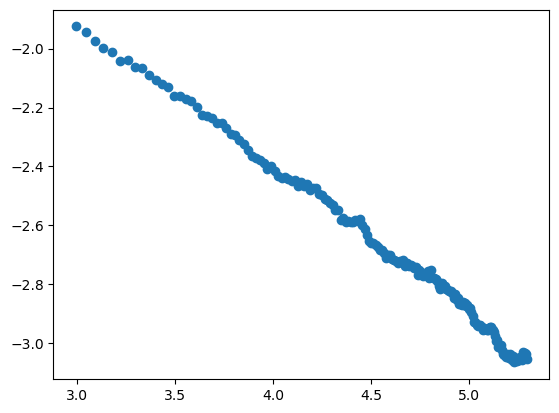

In [10]:
x = time[20:200]
y = np.array(mean_densities)
y= np.log(y[-1, x])
x = np.log(x)
plt.scatter(x,y)
plt.show()

In [11]:
result = sp.stats.linregress(x,y)
print(result)

LinregressResult(slope=np.float64(-0.5033115946777662), intercept=np.float64(-0.3857822277173302), rvalue=np.float64(-0.9973048223866129), pvalue=np.float64(6.904052644993389e-204), stderr=np.float64(0.002775331632562978), intercept_stderr=np.float64(0.012728052095953093))


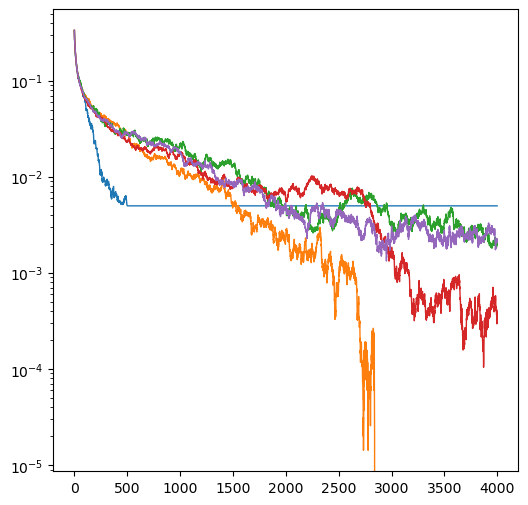

In [18]:
fig, ax2 = plt.subplots(figsize = (6,6))
for d in mean_densities:
    ax2.plot(time, d, lw = 1)
ax2.set_yscale('log')
plt.show()

### Pair Correlation function

In [46]:
initial_density = 0.4
L = 250
T = 5000

def count_neighbors(world):
    return ( np.roll(world,1,0) + np.roll(world,-1,0) + np.roll(world,1,1) + np.roll(world,-1,1) +
             np.roll(np.roll(world,1,0),1,1) + np.roll(np.roll(world,1,0),-1,1) + 
             np.roll(np.roll(world,-1,0),1,1) + np.roll(np.roll(world,-1,0),-1,1) )

def evolve(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    return new_world

def pair_correlation_function(world, r_max):
    coord = np.argwhere(world == 1)
    diff = np.abs(coord[:,None,:] - coord[None,:,:])
    diff = np.minimum(diff,world.shape-diff)
    dist = np.sqrt(np.sum(diff**2, axis=2))
    dist = dist[np.triu_indices(dist.shape[0], 1)]
    hist, bin_edges = np.histogram(dist, bins=50, range=(0, r_max), density=False)
    r = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    dr = bin_edges[1]-bin_edges[0]
    N = np.sum(world == 1)
    mean_density = N/L**2
    hist = (1/(N*mean_density*np.pi*dr))*hist/r
    return (hist, bin_edges, r, dr)
    
world = np.random.random((L,L))
world[world > initial_density] = 0
world[world != 0] = 1

r_max = L/2
pair_corr_funcs = []
for t in range(T):
    world = evolve(world)
    if( t % int(T/10) == 0):
        pair_corr_funcs.append(pair_correlation_function(world, r_max))    


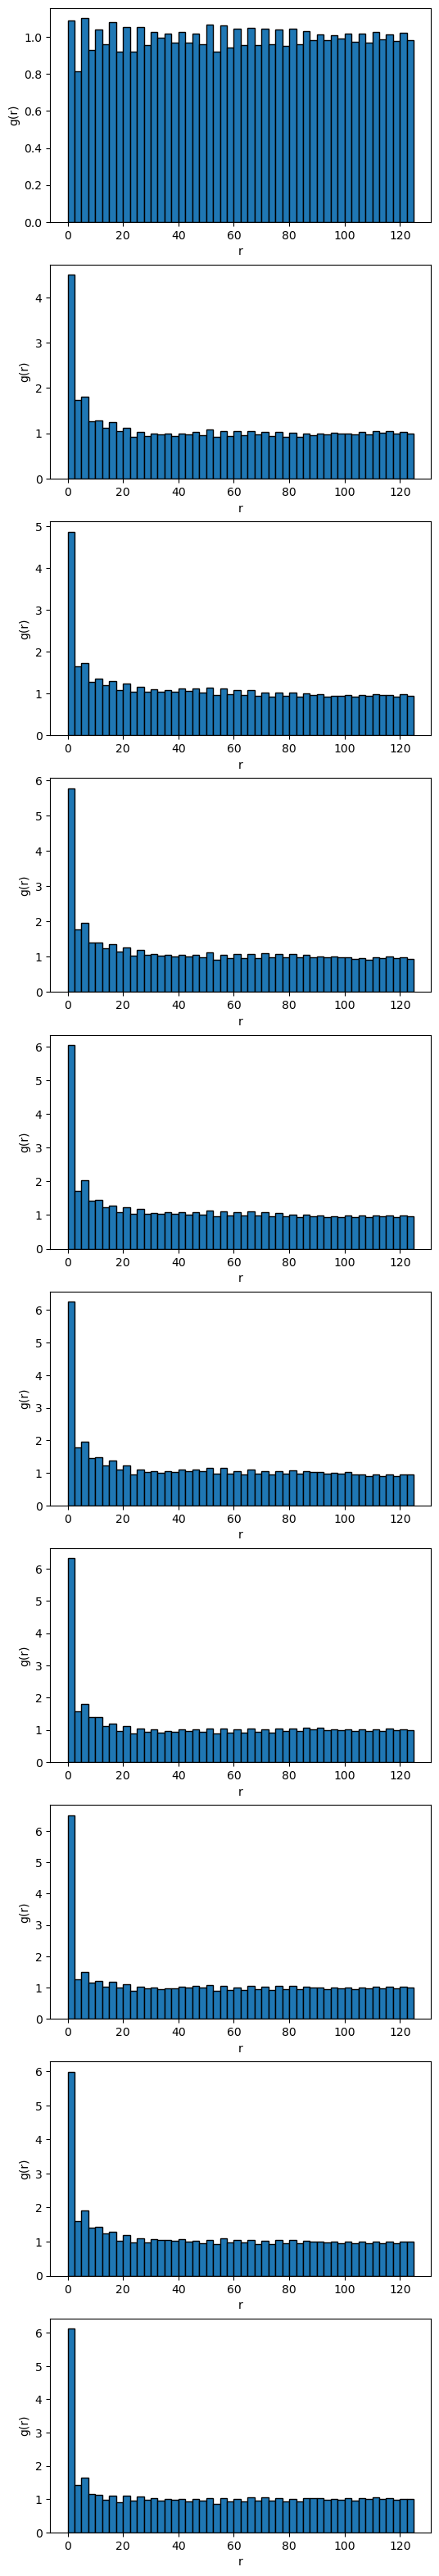

In [47]:
fig, ax4 = plt.subplots(nrows = len(pair_corr_funcs), figsize = (6,40))

for i in range(len(pair_corr_funcs)):
    ax4[i].bar(pair_corr_funcs[i][2], pair_corr_funcs[i][0], width = pair_corr_funcs[i][3], edgecolor = 'k', align = 'center')
    #ax4[i].plot(pair_corr_funcs[i][2], pair_corr_funcs[i][0])
    ax4[i].set_xlabel("r")
    ax4[i].set_ylabel("g(r)")

plt.show()

### Activity

In [6]:
initial_density = 0.4
L = 150
T = 1000
time = np.arange(T)
N = 100 #trajectories
def evolve_with_activity(world):
    neighbors = count_neighbors(world)
    new_world = np.zeros(world.shape)
    mask = ( (world==1) & ( (neighbors==2) | (neighbors==3) ) ) | ( (world==0) & (neighbors==3) )
    new_world[mask] = 1
    births = np.sum((world == 0) & (new_world == 1))
    deaths = np.sum((world == 1) & (new_world == 0))
    alive = np.sum(world)
    activity = (births + deaths)/alive
    return new_world, births/alive, deaths/alive, activity

mean_activity = []
for i in range(N):
    aux_births = []
    aux_deaths = []
    aux_activity = []
    world = np.random.random((L,L))
    world[world > initial_density] = 0
    world[world != 0] = 1
    for t in range(T):
        world, births, deaths, activity = evolve_with_activity(world)
        aux_births.append(births)
        aux_deaths.append(deaths)
        aux_activity.append(activity)
    mean_births.append(aux_births)
    mean_deaths.append(aux_deaths)
    mean_activity.append(aux_activity)
mean_births = np.array(mean_births).mean(axis = 0)
mean_deaths = np.array(mean_deaths).mean(axis = 0)
mean_activity = np.array(mean_activity).mean(axis = 0)

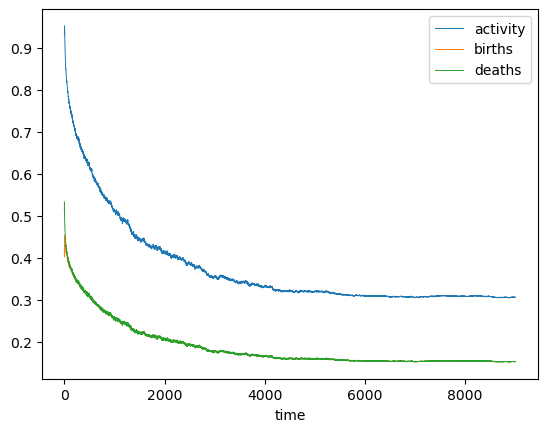

In [7]:
plt.plot(time, mean_activity, lw = 0.7, label = "activity")
plt.plot(time, mean_births, lw = 0.7, label = "births")
plt.plot(time, mean_deaths, lw = 0.7, label = "deaths")
plt.xlabel("time")
plt.legend()
plt.show()

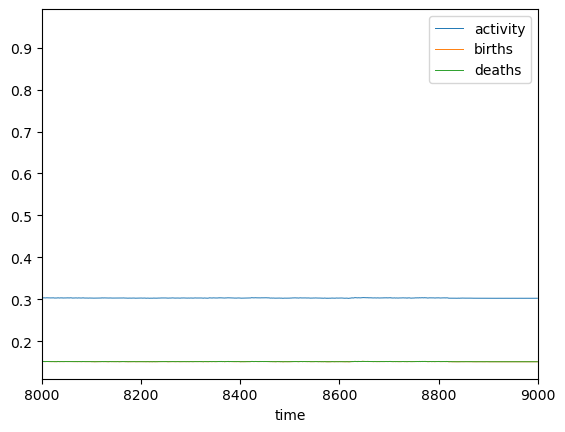

In [83]:
plt.plot(time, mean_activity, lw = 0.7, label = "activity")
plt.plot(time, mean_births, lw = 0.7, label = "births")
plt.plot(time, mean_deaths, lw = 0.7, label = "deaths")
plt.xlabel("time")
plt.xlim(8000,9000)
#plt.ylim(0.2,0.35)
plt.legend()
plt.show()

Asymptotic activity

In [87]:
initial_density = 0.4
L = np.array([50,80,100,150,200])
#L=np.array([50,100])

T = 9000
DT = 500
N = np.array([80,30,20,10,10])
time = np.arange(T,T+DT)

for k in range(len(L)):
    print("Lattice size: ", L[k],"x", L[k])
    densities = []
    activities = []
    for i in range(N[k]):
        aux_density = []
        aux_activity = []
        world = np.random.random((L[k],L[k]))
        world[world > initial_density] = 0
        world[world != 0] = 1
        for j in range(T):
            world = evolve(world)
        for j in range(T,T+DT):
            world, births, deaths, activity = evolve_with_activity(world)
            aux_density.append(np.sum(world)/L[k]**2)
            aux_activity.append(activity)
        densities.append(aux_density)
        activities.append(aux_activity)
        
    print("mean asymptotic density: ", np.mean(np.array(densities)), " +/- ", np.std(np.array(densities)))
    print("mean asymptotic activity: ", np.mean(np.array(activities)), " +/- ", np.std(np.array(activities)))

Lattice size:  50 x 50
mean asymptotic density:  0.030279999999999994  +/-  0.007079802257125547
mean asymptotic activity:  0.34366171470500617  +/-  0.1572045834310292
Lattice size:  80 x 80
mean asymptotic density:  0.02939583333333333  +/-  0.0036613286783587487
mean asymptotic activity:  0.29730359962634856  +/-  0.10377781415970254
Lattice size:  100 x 100
mean asymptotic density:  0.028555  +/-  0.00471894850575846
mean asymptotic activity:  0.2817704851388958  +/-  0.09081441014594227
Lattice size:  150 x 150
mean asymptotic density:  0.02905777777777778  +/-  0.0023136140292933927
mean asymptotic activity:  0.32544881573881884  +/-  0.04084898546501738
Lattice size:  200 x 200
mean asymptotic density:  0.027255  +/-  0.0014035579788523173
mean asymptotic activity:  0.3030364183869219  +/-  0.03292822944713494


In [18]:
L = np.array([50, 100, 150, 200, 240])
N = np.array([100, 20, 10, 10, 10])
initial_density = 0.4
T = 5000

mean_activities = []
for k in range(len(L)):
    mean_activity = []
    for i in range(N[k]):
        world = np.random.random((L[k],L[k]))
        world[world > initial_density] = 0
        world[world != 0] = 1
        aux_activity = []
        for t in range(T):
            world, births, deaths, activity = evolve_with_activity(world)
            aux_activity.append(activity-0.3)
        mean_activity.append(aux_activity)
    mean_activities.append(np.array(mean_activity).mean(axis = 0))

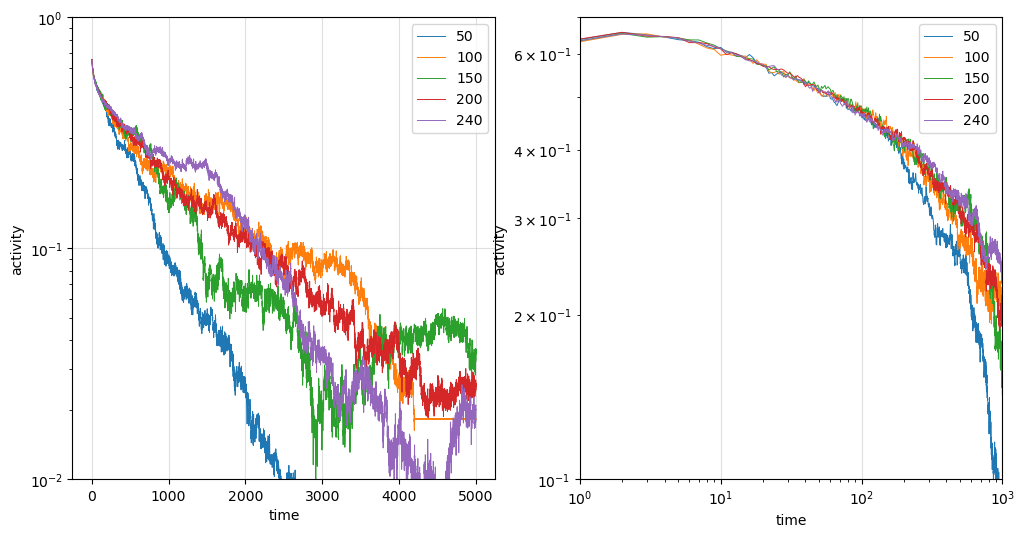

In [32]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
for i in range(len(mean_activities)):
    ax[0].plot(range(T), mean_activities[i], lw = 0.7, label = f"{L[i]}")
ax[0].set_yscale("log")
ax[0].set_ylim(0.01,1)
#ax[0].set_xlim(10,100)
ax[0].set_xlabel("time")
ax[0].set_ylabel("activity")
ax[0].legend()
ax[0].grid(alpha = 0.4)

for i in range(len(mean_activities)):
    ax[1].plot(range(T), mean_activities[i], lw = 0.7, label = f"{L[i]}")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_ylim(0.1,0.7)
ax[1].set_xlim(1,1000)
ax[1].set_xlabel("time")
ax[1].set_ylabel("activity")
ax[1].legend()
ax[1].grid(alpha = 0.4)

plt.show()

b:  0.1345585438714666  +/-  0.0023573848434624923


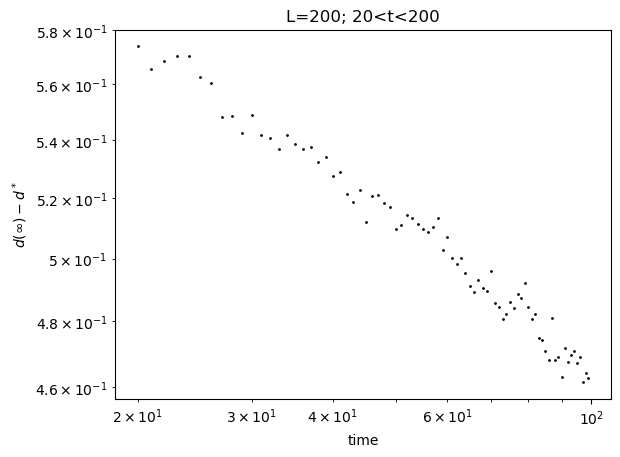

In [41]:
x = range(20,100)
y = np.array(mean_activities)[-1, x]
plt.scatter(x,y, s = 1, color = "black")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("time")
plt.ylabel(r"$d(\infty)-d^*$")
plt.title("L=200; 20<t<200")

x = np.log(x)
y = np.log(y)


def func(x, m, q):
    return m*x + q
    
popt, pcov = sp.optimize.curve_fit(func, x, y)

b, q = popt
errb, errq = np.sqrt(np.diag(pcov))

print("b: ", -b, " +/- ", errb)
xlin = np.linspace(x.min(), x.max())
# plt.scatter(x,y, s = 2, color = "black")
# plt.plot(xlin, func(xlin,b,q), color = "red", lw = 0.7)
# plt.show()
plt.show()

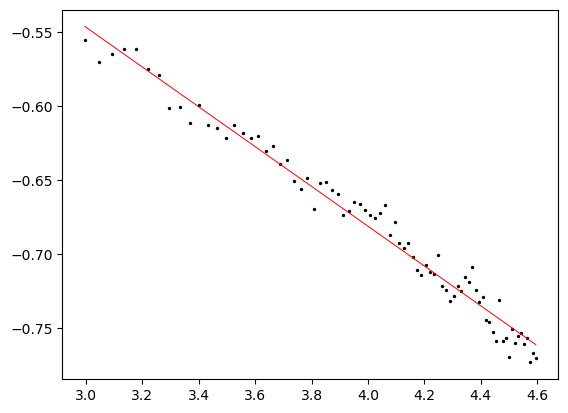

In [42]:
plt.scatter(x,y, s = 2, color = "black")
plt.plot(xlin, func(xlin,b,q), color = "red", lw = 0.7)
plt.show()